In [12]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.metrics import classification_report, f1_score

import warnings
warnings.filterwarnings('ignore')


## 1: Load and Preprocess Data

In [13]:
# Load your fully feature-engineered dataset

# df = pd.read_csv("feature_engineering/data_with_new_features.csv")
# participant_col_name = 'participant'

df = pd.read_csv("../data_cleaning/data/imputed_data.csv")
participant_col_name = 'person'


In [14]:
# Exclude non-numeric columns
exclude_cols = [participant_col_name, 'timestamp', 'genre']
numeric_cols = df.drop(columns=exclude_cols).select_dtypes(include=[np.number]).columns.tolist()

# Global normalization
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


In [15]:
# Encode other categorical columns (if any, excluding participant/timestamp/genre)
categorical_cols = df.select_dtypes(include=['object']).columns.difference([participant_col_name, 'timestamp', 'genre'])

for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

# Encode the target variable 'genre'
genre_label_encoder = LabelEncoder()
df['genre_encoded'] = genre_label_encoder.fit_transform(df['genre'])


## 2. Train/Val/Test Split by Participants

In [16]:
# Split Clara for test only
test_df = df[df[participant_col_name] == 'clara'].copy()

# Combine Kenji and Aimen data
train_val_df = df[df[participant_col_name].isin(['kenji', 'aimen'])].copy()

# Stratified split into train (80%) and val (20%) from Kenji + Aimen
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.2,
    stratify=train_val_df['genre_encoded'],
    random_state=42
)

# Final test set is Clara
final_test_df = test_df.copy()

In [17]:
# define features and labels
X_train = train_df[numeric_cols]
y_train = train_df['genre_encoded']

X_val = val_df[numeric_cols]
y_val = val_df['genre_encoded']

X_test = final_test_df[numeric_cols]
y_test = final_test_df['genre_encoded']

## 3. RFECV for Feature Selection

In [18]:
rf = RandomForestClassifier(n_estimators=75, max_depth=25, min_samples_split=15, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rfecv = RFECV(estimator=rf, step=1, cv=cv, scoring='f1_weighted', n_jobs=-1)
rfecv.fit(X_train, y_train)

# Reduce features
X_train_sel = rfecv.transform(X_train)
X_val_sel = rfecv.transform(X_val)
X_test_sel = rfecv.transform(X_test)


In [19]:
feature_ranks = pd.DataFrame({
    'feature': X_train.columns,
    'rank': rfecv.ranking_
}).sort_values(by='rank')

print(feature_ranks)

             feature  rank
0         heart_rate     1
1       x_coordinate     1
2       y_coordinate     1
3  pupil_diameter_mm     1
5   pupil_iris_ratio     1
4   iris_diameter_mm     2


## 4. Train and Evaluate Final Random Forest

In [20]:
rf_final = RandomForestClassifier(n_estimators=75, max_depth=25, min_samples_split=15, random_state=42)
rf_final.fit(X_train_sel, y_train)

# Validation
val_preds = rf_final.predict(X_val_sel)
print("Validation Report:\n", classification_report(y_val, val_preds))

# Test
test_preds = rf_final.predict(X_test_sel)
print("Test Report:\n", classification_report(y_test, test_preds))

Validation Report:
               precision    recall  f1-score   support

           0       0.94      0.94      0.94       324
           1       0.98      0.94      0.96       296
           2       0.93      0.95      0.94       428

    accuracy                           0.95      1048
   macro avg       0.95      0.95      0.95      1048
weighted avg       0.95      0.95      0.95      1048

Test Report:
               precision    recall  f1-score   support

           0       0.23      0.03      0.06      1340
           1       0.42      0.90      0.57      1560
           2       0.98      0.46      0.62      1216

    accuracy                           0.49      4116
   macro avg       0.54      0.46      0.42      4116
weighted avg       0.52      0.49      0.42      4116



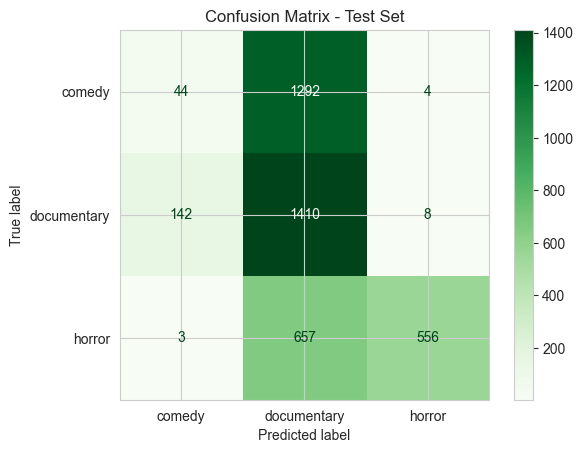

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Test confusion matrix
test_cm = confusion_matrix(y_test, test_preds)
test_disp = ConfusionMatrixDisplay(confusion_matrix=test_cm, display_labels=genre_label_encoder.classes_)
test_disp.plot(cmap='Greens')
plt.title("Confusion Matrix - Test Set")
plt.show()


In [22]:
# RF works better with raw features